Customer Location and Cluster
--------------------------------
Customer 1: Location = [1. 1.], Cluster = 0
Customer 2: Location = [1.2 1.1], Cluster = 0
Customer 3: Location = [1.1 1.3], Cluster = 0
Customer 4: Location = [1.3 1.2], Cluster = 0
Customer 5: Location = [0.9 1.1], Cluster = 0
Customer 6: Location = [5. 5.], Cluster = 1
Customer 7: Location = [5.2 5.1], Cluster = 1
Customer 8: Location = [5.1 5.3], Cluster = 1
Customer 9: Location = [5.3 5.2], Cluster = 1
Customer 10: Location = [4.9 5.1], Cluster = 1
Customer 11: Location = [9. 2.], Cluster = 2
Customer 12: Location = [9.2 2.1], Cluster = 2
Customer 13: Location = [9.1 2.3], Cluster = 2
Customer 14: Location = [9.3 2.2], Cluster = 2
Customer 15: Location = [8.9 2.1], Cluster = 2
Customer 16: Location = [15. 10.], Cluster = -1
Customer 17: Location = [20. 15.], Cluster = -1

Potential Hub Locations
--------------------------------
Cluster 0: Customers = 5, Hub Location = [1.1  1.14]
Cluster 1: Customers = 5, Hub Location =

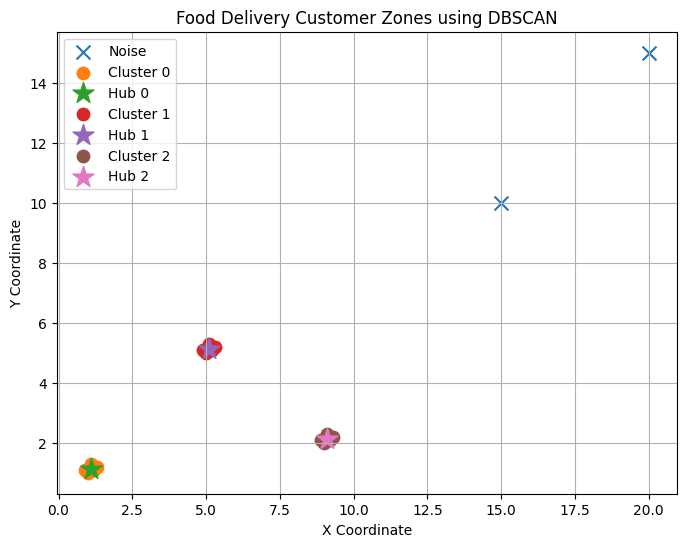

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Step 1: Customer location coordinates

X = np.array([
    [1.0, 1.0],
    [1.2, 1.1],
    [1.1, 1.3],
    [1.3, 1.2],
    [0.9, 1.1],

    [5.0, 5.0],
    [5.2, 5.1],
    [5.1, 5.3],
    [5.3, 5.2],
    [4.9, 5.1],

    [9.0, 2.0],
    [9.2, 2.1],
    [9.1, 2.3],
    [9.3, 2.2],
    [8.9, 2.1],

    [15.0, 10.0],
    [20.0, 15.0]
])

# Step 2: Apply DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=3)

labels = dbscan.fit_predict(X)

# Step 3: Display cluster labels


print("Customer Location and Cluster")
print("--------------------------------")

for i, (point, label) in enumerate(zip(X, labels), start=1):
    print(
        f"Customer {i}: Location = {point}, "
        f"Cluster = {label}"
    )


# Step 4: Find potential hub locations

print("\nPotential Hub Locations")
print("--------------------------------")

for label in sorted(set(labels)):

    # -1 represents noise
    if label == -1:
        continue

    cluster_points = X[labels == label]

    # Calculate center of cluster
    centroid = cluster_points.mean(axis=0)

    print(
        f"Cluster {label}: "
        f"Customers = {len(cluster_points)}, "
        f"Hub Location = {centroid}"
    )


# Step 5: Visualize clusters

plt.figure(figsize=(8, 6))

for label in sorted(set(labels)):

    cluster_points = X[labels == label]

    if label == -1:

        # Noise points
        plt.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            marker='x',
            s=100,
            label='Noise'
        )

    else:

        # Cluster points
        plt.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            s=80,
            label=f'Cluster {label}'
        )

        # Calculate centroid
        centroid = cluster_points.mean(axis=0)

        # Mark potential hub
        plt.scatter(
            centroid[0],
            centroid[1],
            marker='*',
            s=250,
            label=f'Hub {label}'
        )

# Step 6: Add graph details

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Food Delivery Customer Zones using DBSCAN")
plt.legend()
plt.grid(True)

plt.show()
